# Canadian Metropolitan Job Postings Analysis (2020–2026)

This notebook analyzes the **Indeed Job Postings Index** across **45 Canadian Census Metropolitan Areas (CMAs)** from February 2020 through August 2026 (`data/metro_job_postings_CA.csv`).

### Key Objectives:
1. **Current Standing**: Identify which Canadian metros have recovered above pre-pandemic levels (index > 100) vs those still below.
2. **Tech & Economic Hubs**: Deep-dive into Canada's core tech markets (**Toronto, Vancouver, Montreal, Ottawa, KWC, Calgary, Edmonton**).
3. **Cycle Dynamics**: Measure the 2020 crash, 2021–2022 hiring peak, and 2023–2026 cool-down.
4. **YoY Momentum**: Evaluate which metropolitan markets are accelerating or lagging over the past 12 months.

In [1]:
%matplotlib inline
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual styling setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Resolve project repository root and ensure output plots directory exists
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data_extraction/sources.json").exists())
os.chdir(ROOT)
Path("data_analysis/01_posting_indices/plots").mkdir(parents=True, exist_ok=True)

print("Setup complete. Root directory:", ROOT)

Setup complete. Root directory: /home/althaaf/JOB_SEARCH/project/PYTHON/job_analysis


## 1. Load and Clean the Metro Dataset

In [2]:
# Load Canadian metro job posting indices
df = pd.read_csv('data/metro_job_postings_CA.csv')
df['date'] = pd.to_datetime(df['date'])

# Extract province code from metro string (e.g. 'Toronto, ON' -> 'ON')
df['Province'] = df['Metro'].apply(lambda x: x.split(',')[-1].strip() if ',' in x else 'Other')

# Dataset span and geography overview
print(f"Total records: {len(df):,}")
print(f"Date coverage: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Total unique metros: {df['Metro'].nunique()}")
df.head()

Total records: 108,045
Date coverage: 2020-02-01 to 2026-08-28
Total unique metros: 45


,date,Metro,indeed_job_postings_index,Province
0,2020-02-01,"Abbotsford, BC",100.00,BC
1,2020-02-02,"Abbotsford, BC",99.61,BC
2,2020-02-03,"Abbotsford, BC",99.09,BC
3,2020-02-04,"Abbotsford, BC",98.66,BC
4,2020-02-05,"Abbotsford, BC",98.43,BC


## 2. Latest Snapshot: Top 10 vs Bottom 10 Metros

The index is normalized to **100 on February 1, 2020** (pre-pandemic baseline).
- **> 100**: Active job openings exceed pre-pandemic levels.
- **< 100**: Active job openings remain below pre-pandemic baseline.

/tmp/ipykernel_3969838/2126663411.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='indeed_job_postings_index', y='Metro', ax=ax1, palette='Blues_r')
/tmp/ipykernel_3969838/2126663411.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_10, x='indeed_job_postings_index', y='Metro', ax=ax2, palette='Reds_r')


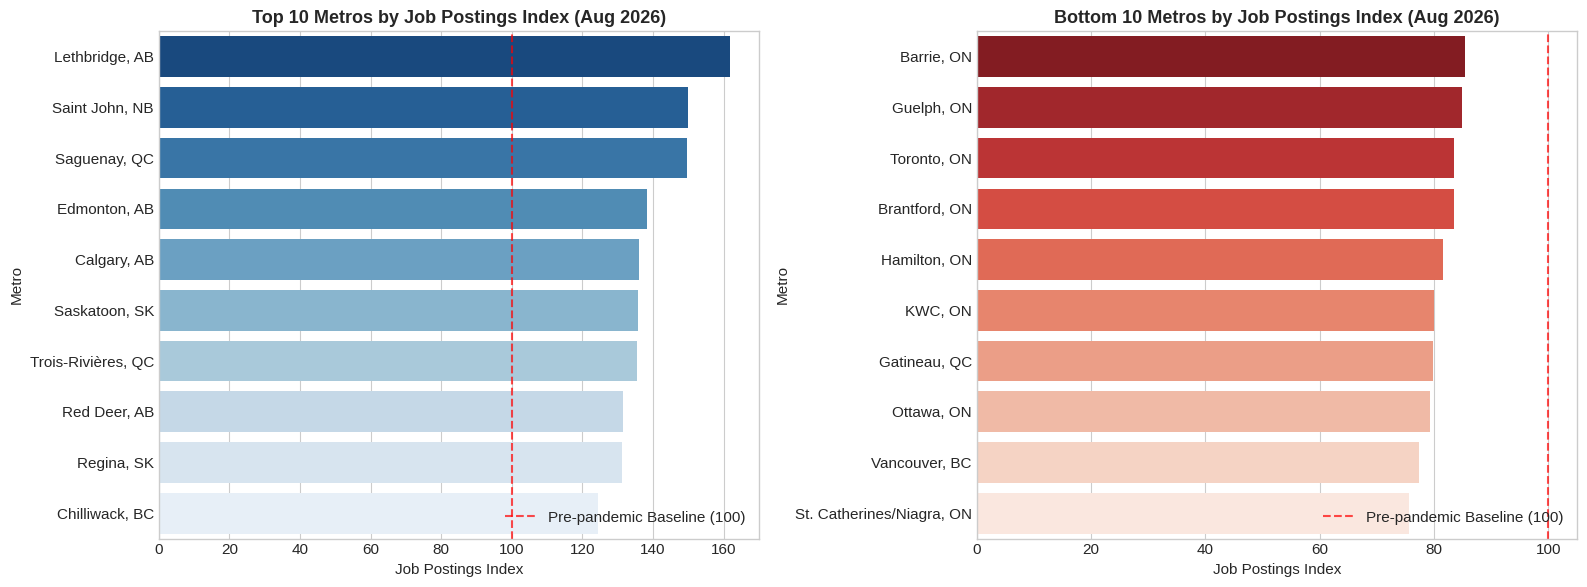

In [3]:
# Rank metros at the latest recorded date to identify extremes
latest_date = df['date'].max()
latest_df = df[df['date'] == latest_date].sort_values(by='indeed_job_postings_index', ascending=False).reset_index(drop=True)

top_10 = latest_df.head(10)
bottom_10 = latest_df.tail(10)

# Two-panel plot: Top 10 strongest vs. Bottom 10 weakest metros
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Top 10 highest index metros
sns.barplot(data=top_10, x='indeed_job_postings_index', y='Metro', ax=ax1, palette='Blues_r')
ax1.axvline(100, color='red', linestyle='--', alpha=0.7, label='Pre-pandemic Baseline (100)')
ax1.set_title(f'Top 10 Metros by Job Postings Index ({latest_date.strftime("%b %Y")})')
ax1.set_xlabel('Job Postings Index')
ax1.legend(loc='lower right')

# Panel 2: Bottom 10 lowest index metros
sns.barplot(data=bottom_10, x='indeed_job_postings_index', y='Metro', ax=ax2, palette='Reds_r')
ax2.axvline(100, color='red', linestyle='--', alpha=0.7, label='Pre-pandemic Baseline (100)')
ax2.set_title(f'Bottom 10 Metros by Job Postings Index ({latest_date.strftime("%b %Y")})')
ax2.set_xlabel('Job Postings Index')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('data_analysis/01_posting_indices/plots/metro_top_bottom_rankings.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. Major Canadian Tech & Innovation Hubs

Let's focus on the key cities driving the Canadian technology and professional services economy:
- **Toronto, ON** (Financial & Tech capital)
- **Vancouver, BC** (West Coast Tech hub)
- **Montréal, QC** (AI, Gaming, and Software)
- **Ottawa, ON** (Public sector, Telecom & SaaS)
- **KWC, ON** (Kitchener-Waterloo-Cambridge, the University of Waterloo tech corridor)
- **Calgary, AB & Edmonton, AB** (Emerging energy-tech & engineering hubs)
- **Halifax, NS & Victoria, BC** (Maritime & Pacific provincial hubs)

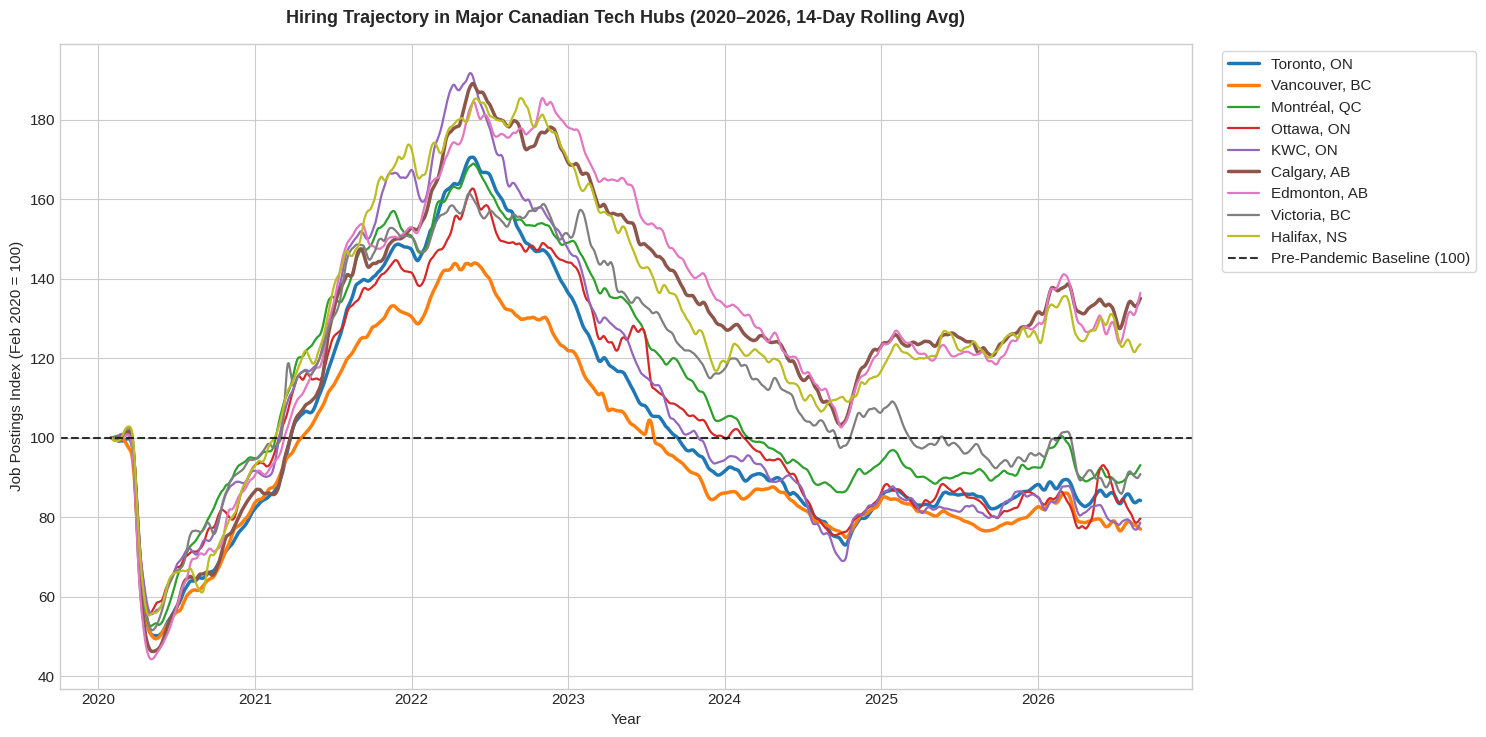

In [4]:
# Select primary Canadian tech hubs and major regional centers
tech_hubs = [
    'Toronto, ON',
    'Vancouver, BC',
    'Montréal, QC',
    'Ottawa, ON',
    'KWC, ON',
    'Calgary, AB',
    'Edmonton, AB',
    'Victoria, BC',
    'Halifax, NS'
]

# Filter and pivot into time-series by hub
df_tech = df[df['Metro'].isin(tech_hubs)].copy()
pivot_tech = df_tech.pivot_table(index='date', columns='Metro', values='indeed_job_postings_index')

# Smooth with a 14-day rolling average to reduce short-term volatility
pivot_smooth = pivot_tech.rolling(window=14, min_periods=1).mean()

# Plot multi-year trajectory across tech hubs
plt.figure(figsize=(15, 7.5))
palette = sns.color_palette('tab10', len(tech_hubs))

for i, hub in enumerate(tech_hubs):
    # Emphasize major anchor markets with thicker lines
    linewidth = 2.5 if hub in ['Toronto, ON', 'Vancouver, BC', 'Calgary, AB'] else 1.6
    plt.plot(pivot_smooth.index, pivot_smooth[hub], label=hub, linewidth=linewidth, color=palette[i])

plt.axhline(100, color='black', linestyle='--', linewidth=1.5, alpha=0.8, label='Pre-Pandemic Baseline (100)')
plt.title('Hiring Trajectory in Major Canadian Tech Hubs (2020–2026, 14-Day Rolling Avg)', pad=15)
plt.xlabel('Year')
plt.ylabel('Job Postings Index (Feb 2020 = 100)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('data_analysis/01_posting_indices/plots/metro_tech_hubs_trajectory.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Peak-to-Trough Cycle Analysis

Calculate how each major tech hub performed through the three distinct market regimes:
1. **The 2020 Crash** (Initial lockdown trough in Spring 2020)
2. **The 2021–2022 Tech Boom Peak** (Peak post-pandemic hiring stimulus)
3. **The Current Level & Drawdown** (Post-2023 normalization / contraction from all-time highs)

In [5]:
# Measure each hub's full cycle: 2020 pandemic trough, peak expansion, and current drawdown
cycle_records = []

for hub in tech_hubs:
    hdata = df[df['Metro'] == hub]
    trough_2020 = hdata[hdata['date'] < '2021-01-01'].loc[hdata[hdata['date'] < '2021-01-01']['indeed_job_postings_index'].idxmin()]
    peak = hdata.loc[hdata['indeed_job_postings_index'].idxmax()]
    latest_val = hdata[hdata['date'] == latest_date]['indeed_job_postings_index'].values[0]
    
    # Calculate percentage contraction from peak and net difference from baseline
    peak_val = peak['indeed_job_postings_index']
    drawdown_pct = ((latest_val - peak_val) / peak_val) * 100
    vs_baseline_pct = latest_val - 100
    
    cycle_records.append({
        'Metro': hub,
        '2020 Trough Index': round(trough_2020['indeed_job_postings_index'], 1),
        'Trough Date': trough_2020['date'].strftime('%Y-%m'),
        'Peak Index': round(peak_val, 1),
        'Peak Date': peak['date'].strftime('%Y-%m'),
        'Latest Index': round(latest_val, 1),
        'Drawdown from Peak (%)': round(drawdown_pct, 1),
        'Net vs Feb 2020 Baseline (%)': round(vs_baseline_pct, 1)
    })

# Sort table by latest index value
cycle_df = pd.DataFrame(cycle_records).sort_values(by='Latest Index', ascending=False).reset_index(drop=True)
cycle_df

,Metro,2020 Trough Index,Trough Date,Peak Index,Peak Date,Latest Index,Drawdown from Peak (%),Net vs Feb 2020 Baseline (%)
0,"Edmonton, AB",43.9,2020-04,186.7,2022-10,138.2,-26.0,38.2
1,"Calgary, AB",46.1,2020-04,189.4,2022-05,136.2,-28.1,36.2
2,"Halifax, NS",54.1,2020-04,187.2,2022-09,124.1,-33.7,24.1
3,"Montréal, QC",52.2,2020-04,169.5,2022-05,93.8,-44.7,-6.2
4,"Victoria, BC",51.3,2020-04,162.3,2022-05,92.2,-43.2,-7.8
5,"Toronto, ON",49.9,2020-05,170.9,2022-05,83.5,-51.1,-16.5
6,"KWC, ON",55.3,2020-04,192.5,2022-05,80.0,-58.4,-20.0
7,"Ottawa, ON",55.0,2020-04,163.2,2022-05,79.4,-51.4,-20.7
8,"Vancouver, BC",49.1,2020-05,145.0,2022-05,77.3,-46.7,-22.7


## 5. Year-over-Year (YoY) Momentum (August 2025 vs August 2026)

Examining recent 1-year momentum to see which tech markets have found a bottom or begun re-accelerating.

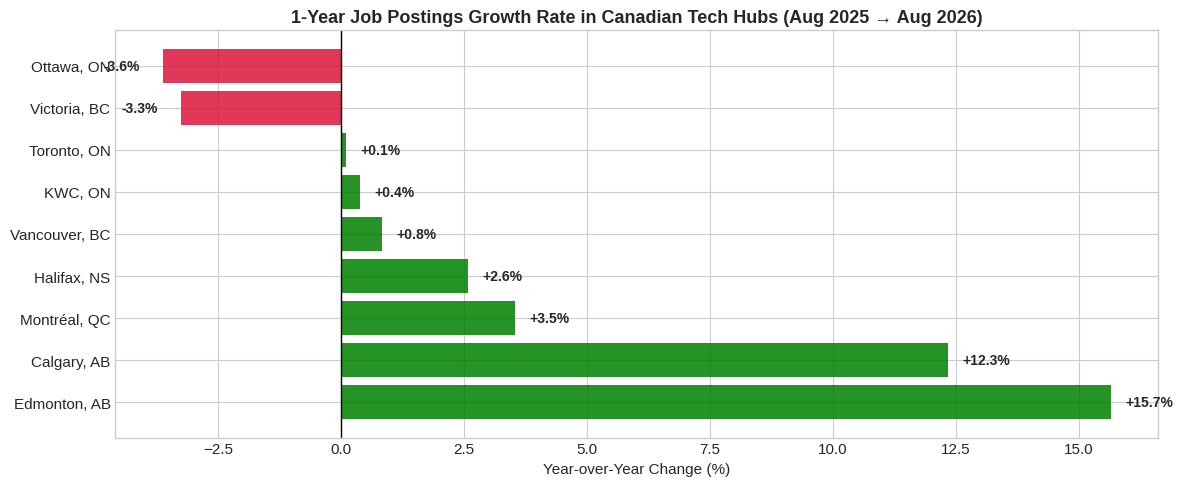

,Metro,index_2025,index_2026,YoY_Growth_Pct
0,"Edmonton, AB",119.51,138.22,15.655594
1,"Calgary, AB",121.20,136.16,12.343234
2,"Montréal, QC",90.58,93.79,3.543829
3,"Halifax, NS",120.93,124.06,2.588274
4,"Vancouver, BC",76.63,77.27,0.835182
5,"KWC, ON",79.67,79.98,0.389105
6,"Toronto, ON",83.42,83.51,0.107888
7,"Victoria, BC",95.32,92.22,-3.252203
8,"Ottawa, ON",82.33,79.35,-3.619580


In [6]:
# Compute 1-year change comparing August 2025 with August 2026
aug_2025 = pd.to_datetime('2025-08-28')
df_aug25 = df[df['date'] == aug_2025][['Metro', 'indeed_job_postings_index']].rename(columns={'indeed_job_postings_index': 'index_2025'})
df_aug26 = df[df['date'] == latest_date][['Metro', 'indeed_job_postings_index']].rename(columns={'indeed_job_postings_index': 'index_2026'})

yoy_df = pd.merge(df_aug25, df_aug26, on='Metro')
yoy_df['YoY_Growth_Pct'] = ((yoy_df['index_2026'] - yoy_df['index_2025']) / yoy_df['index_2025']) * 100

# Filter for major tech hubs
yoy_tech = yoy_df[yoy_df['Metro'].isin(tech_hubs)].sort_values(by='YoY_Growth_Pct', ascending=False).reset_index(drop=True)

# Horizontal bar chart: green for year-over-year gains, red for contractions
plt.figure(figsize=(12, 5))
colors = ['green' if x > 0 else 'crimson' for x in yoy_tech['YoY_Growth_Pct']]
bars = plt.barh(yoy_tech['Metro'], yoy_tech['YoY_Growth_Pct'], color=colors, alpha=0.85)
plt.axvline(0, color='black', linewidth=1)
plt.title('1-Year Job Postings Growth Rate in Canadian Tech Hubs (Aug 2025 → Aug 2026)')
plt.xlabel('Year-over-Year Change (%)')

# Annotate percentage labels on bars
for bar in bars:
    val = bar.get_width()
    offset = 0.3 if val >= 0 else -1.2
    plt.text(val + offset, bar.get_y() + bar.get_height()/2, f'{val:+.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('data_analysis/01_posting_indices/plots/metro_yoy_growth.png', dpi=130, bbox_inches='tight')
plt.show()
yoy_tech

## 6. Provincial Comparison of Metros

Compare the distribution of metro job index performance aggregated by province.

/tmp/ipykernel_3969838/3266340533.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=latest_full, x='Province', y='indeed_job_postings_index', order=order, palette='Set2')


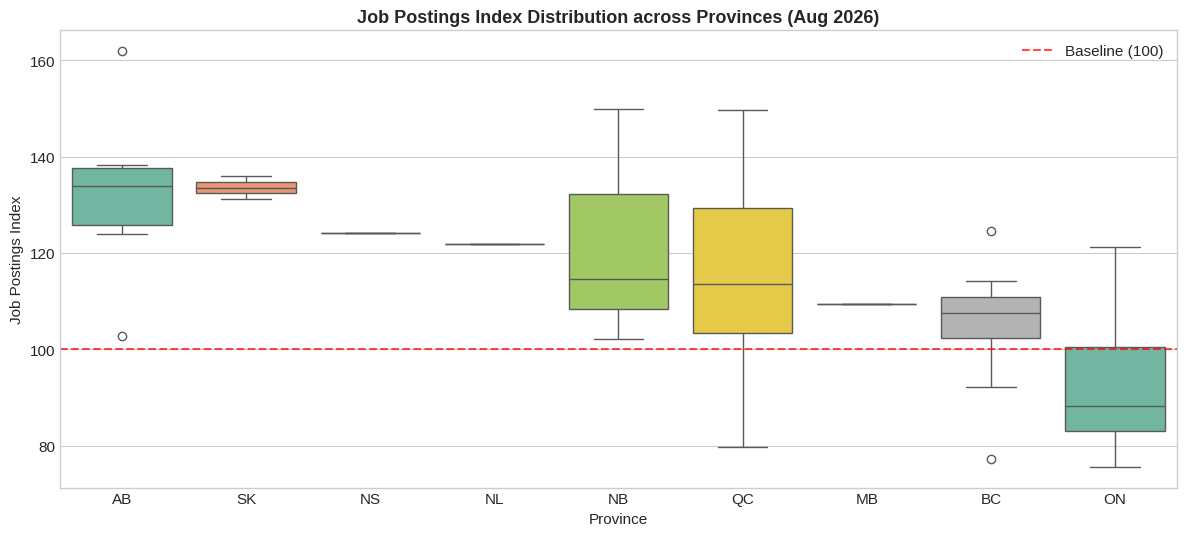

,Metro Count,Mean Index,Median Index,Min Index,Max Index
Province,,,,,
AB,6,132.413333,133.815,102.81,161.93
SK,2,133.600000,133.600,131.31,135.89
NS,1,124.060000,124.060,124.06,124.06
NL,1,121.880000,121.880,121.88,121.88
NB,3,122.170000,114.540,102.15,149.82
QC,7,115.464286,113.480,79.75,149.68
MB,1,109.420000,109.420,109.42,109.42
BC,8,104.840000,107.485,77.27,124.55
ON,16,92.885625,88.235,75.59,121.22


In [7]:
# Group latest snapshot by province to compare provincial distribution statistics
latest_full = df[df['date'] == latest_date].copy()
prov_summary = latest_full.groupby('Province')['indeed_job_postings_index'].agg(['count', 'mean', 'median', 'min', 'max']).sort_values(by='median', ascending=False)

# Boxplot comparing city-level index spreads within each province
plt.figure(figsize=(12, 5.5))
order = prov_summary.index.tolist()
sns.boxplot(data=latest_full, x='Province', y='indeed_job_postings_index', order=order, palette='Set2')
plt.axhline(100, color='red', linestyle='--', alpha=0.7, label='Baseline (100)')
plt.title(f'Job Postings Index Distribution across Provinces ({latest_date.strftime("%b %Y")})')
plt.ylabel('Job Postings Index')
plt.xlabel('Province')
plt.legend()
plt.tight_layout()
plt.savefig('data_analysis/01_posting_indices/plots/metro_provincial_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

# Display formatted summary table
prov_summary.columns = ['Metro Count', 'Mean Index', 'Median Index', 'Min Index', 'Max Index']
prov_summary

## 7. Key Findings & Strategic Takeaways for Job Seekers

1. **The Regional Divide**: 
   - **Alberta & Prairies (Calgary, Edmonton, Saskatoon, Regina)** are the strongest job markets in Canada, maintaining posting volumes **30% to 60% above** pre-pandemic levels.
   - **Ontario & British Columbia (Toronto, Vancouver, KWC, Ottawa)** have experienced the deepest post-2022 contraction, currently sitting **16% to 23% below** February 2020 levels.

2. **Tech Market Drawdowns**:
   - Kitchener-Waterloo-Cambridge (KWC) had the largest boom-and-bust cycle (peaked at **192.5**, now at **80.0**, a **-58.4% drawdown**).
   - Toronto and Vancouver peaked in May 2022 at **170.9** and **145.0**, now settling at **83.5** and **77.3** respectively.

3. **Recent Stabilization (2025–2026)**:
   - The steep declines of 2023–2024 have plateaued in Toronto (+0.1% YoY) and Vancouver (+0.8% YoY), indicating the tech hiring market has likely hit its cyclical bottom.
   - Meanwhile, Edmonton (+15.7% YoY) and Calgary (+12.3% YoY) are seeing robust new expansion.